## Prophet Implementation ':\)'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import logging
from tqdm.notebook import tqdm
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
pd.set_option('display.max_columns', None)

In [ ]:
# ---------------------------------------------------------
# 1. Load Parquet & Replicate Teammate's Sample
# ---------------------------------------------------------
print("Loading processed data...")
df_long = pd.read_parquet('../Datasets/processed_electricity_data.parquet', engine='pyarrow')

# Use the EXACT same seed and sample as the Linear Regression notebook
random.seed(42)
all_clients = sorted(df_long['ClientID'].unique().tolist())
sampled_clients = random.sample(all_clients, 30)

# ---------------------------------------------------------
# DEBUG MODE: set to True to run on 3 clients only (~2 min vs ~15 min)
# One representative per problematic cluster for fast iteration
# ---------------------------------------------------------
DEBUG_MODE = False
debug_clients = ['MT_347', 'MT_328', 'MT_013']  # Clusters 0, 1, 3 

if DEBUG_MODE:
    sampled_clients = debug_clients
    print(f"DEBUG MODE: running on {len(sampled_clients)} clients: {sampled_clients}")
else:
    print(f"Starting Prophet evaluation for {len(sampled_clients)} clients. This may take a few minutes...")

Loading processed data...
DEBUG MODE: running on 3 clients: ['MT_347', 'MT_328', 'MT_013']


In [3]:
# ---------------------------------------------------------
# 2. Initialize Metric Trackers
# ---------------------------------------------------------
all_wmapes = []
all_mapes  = []
all_maes   = []
all_mses   = []
all_rmses  = []

In [4]:
# ---------------------------------------------------------
# 3. The Grand Prophet Loop
# ---------------------------------------------------------
all_predictions = {}

for i, client_id in enumerate(tqdm(sampled_clients, desc="Training Prophet Models")):    
    # Isolate and prep client
    client_df = df_long[df_long['ClientID'] == client_id].copy()
    client_df = client_df.rename(columns={'Date': 'ds', 'Consumption': 'y'})
    client_df = client_df.sort_values('ds').reset_index(drop=True)

    # Time Series Split (Holdout Set)
    FORECAST_HORIZON = 96
    train_df = client_df.iloc[:-FORECAST_HORIZON]
    test_df = client_df.iloc[-FORECAST_HORIZON:]

    # Model Training
    # daily_seasonality=False: the lag regressors already encode the daily shape,
    # having Prophet also model it via Fourier terms double-counts the signal and
    # can push the trend component off — this was causing the Cluster 3 over-prediction.
    m = Prophet(changepoint_prior_scale=0.15, daily_seasonality=False)
    m.add_country_holidays(country_name='PT') 
    m.add_regressor('Temp_National_Avg')
    m.add_regressor('Lag_15min')
    m.add_regressor('Lag_24h')
    m.add_regressor('Rolling_Mean_4h')
    m.fit(train_df)

    # --- The Recursive Loop (No Leakage) ---
    future_steps = test_df[['ds', 'Temp_National_Avg']].copy().reset_index(drop=True)
    history_y = list(train_df['y'].values)
    clean_predictions = []

    for step in range(FORECAST_HORIZON):
        current_step = future_steps.iloc[[step]].copy()
        
        # Dynamically calculate lags from the growing history buffer
        current_step['Lag_15min'] = history_y[-1] 
        current_step['Lag_24h'] = history_y[-96]             
        current_step['Rolling_Mean_4h'] = np.mean(history_y[-16:]) 
        
        step_forecast = m.predict(current_step)
        yhat = step_forecast['yhat'].values[0]
        
        clean_predictions.append(yhat)
        history_y.append(yhat)

    # Evaluation
    y_true = test_df['y'].values
    y_pred = np.array(clean_predictions)
    
    # Clip predictions at 0 (electricity consumption cannot be negative)
    y_pred = np.maximum(y_pred, 0)

    # WMAPE (weighted, robust to near-zero clients)
    sum_actual = np.sum(y_true)
    if sum_actual == 0:
        all_wmapes.append(0.0)
    else:
        wmape = np.sum(np.abs(y_true - y_pred)) / sum_actual
        all_wmapes.append(wmape)

    # MAPE (skip clients with near-zero actuals to avoid division by zero)
    nonzero_mask = y_true > 0.1
    if nonzero_mask.sum() > 0:
        mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask]))
    else:
        mape = 0.0
    all_mapes.append(mape)

    all_maes.append(mean_absolute_error(y_true, y_pred))
    all_mses.append(mean_squared_error(y_true, y_pred))
    all_rmses.append(np.sqrt(mean_squared_error(y_true, y_pred)))
    
    all_predictions[client_id] = {
        'test_df': test_df,
        'y_pred': y_pred
    }

Training Prophet Models:   0%|          | 0/3 [00:00<?, ?it/s]

17:36:34 - cmdstanpy - INFO - Chain [1] start processing
17:36:37 - cmdstanpy - INFO - Chain [1] done processing
17:36:43 - cmdstanpy - INFO - Chain [1] start processing
17:37:01 - cmdstanpy - INFO - Chain [1] done processing
17:37:06 - cmdstanpy - INFO - Chain [1] start processing
17:37:09 - cmdstanpy - INFO - Chain [1] done processing


In [5]:
print("--- 30-CLIENT PROPHET BENCHMARK RESULTS ---")
print(f"Average MAPE:  {np.mean(all_mapes):.2%}")
print(f"Average WMAPE: {np.mean(all_wmapes):.2%}")
print(f"Average MAE:   {np.mean(all_maes):.2f} kW")
print(f"Average MSE:   {np.mean(all_mses):.2f}")
print(f"Average RMSE:  {np.mean(all_rmses):.2f} kW")

--- 30-CLIENT PROPHET BENCHMARK RESULTS ---
Average MAPE:  33.13%
Average WMAPE: 29.25%
Average MAE:   77.87 kW
Average MSE:   36752.54
Average RMSE:  121.24 kW


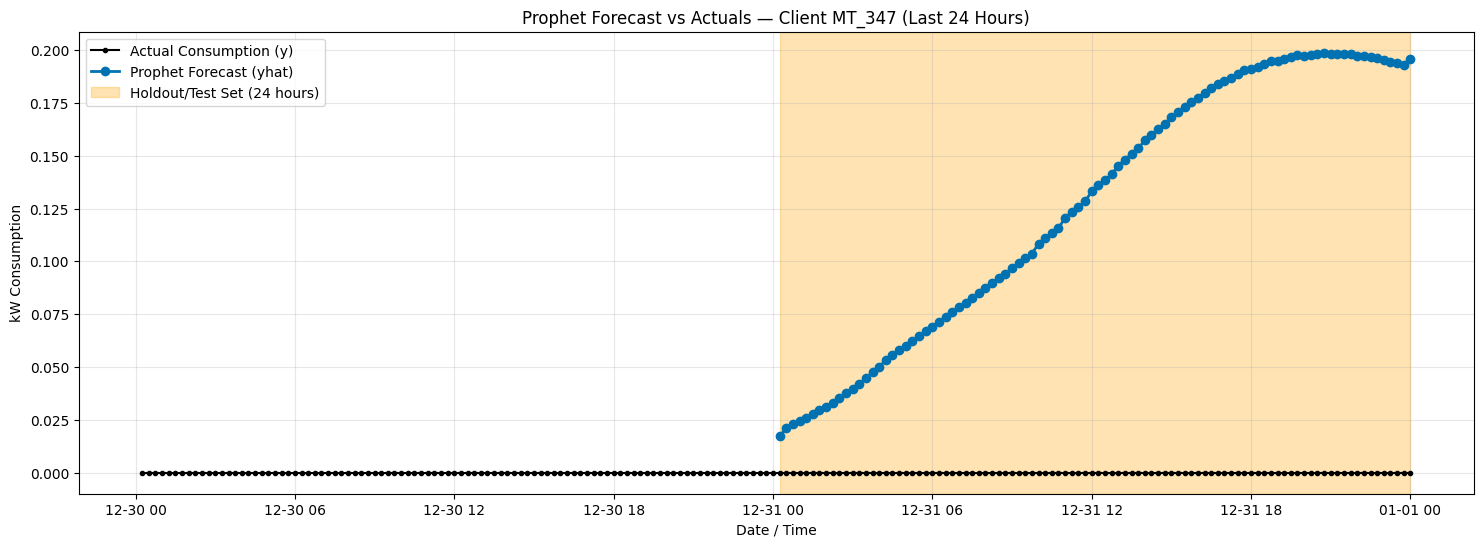

In [6]:
# ---------------------------------------------------------
# 4. Visualization — First client forecast
# ---------------------------------------------------------
first_client = sampled_clients[0]
data = all_predictions[first_client]

zoom_idx = -192

# Rebuild full client df for historical context
client_df = df_long[df_long['ClientID'] == first_client].copy()
client_df = client_df.rename(columns={'Date': 'ds', 'Consumption': 'y'})
client_df = client_df.sort_values('ds').reset_index(drop=True)

plt.figure(figsize=(18, 6))

# Plot the real historical data
plt.plot(client_df['ds'].iloc[zoom_idx:], client_df['y'].iloc[zoom_idx:], 
         label='Actual Consumption (y)', color='black', marker='.', linestyle='-')

# Plot the Prophet forecast
plt.plot(data['test_df']['ds'], data['y_pred'], 
         label='Prophet Forecast (yhat)', color='#0072B2', linewidth=2, marker='o')

# Highlight the holdout area
plt.axvspan(data['test_df']['ds'].iloc[0], data['test_df']['ds'].iloc[-1], 
            color='orange', alpha=0.3, label='Holdout/Test Set (24 hours)')

plt.title(f"Prophet Forecast vs Actuals — Client {first_client} (Last 24 Hours)")
plt.xlabel('Date / Time')
plt.ylabel('kW Consumption')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
# ---------------------------------------------------------
# 5. Performance Breakdown by Cluster
# ---------------------------------------------------------
cluster_map = pd.read_csv('../Datasets/client_clusters.csv')

results_df = pd.DataFrame({
    'ClientID': sampled_clients,
    'MAE':   all_maes,
    'RMSE':  all_rmses,
    'MAPE':  all_mapes,
    'WMAPE': all_wmapes
})

results_df = results_df.merge(cluster_map, on='ClientID')

print("--- PROPHET PERFORMANCE BY CLUSTER ---\n")
summary = results_df.groupby('Cluster').agg(
    n_clients=('ClientID', 'count'),
    MAE=('MAE', 'mean'),
    RMSE=('RMSE', 'mean'),
    MAPE=('MAPE', 'mean'),
    WMAPE=('WMAPE', 'mean')
).round(3)
# Format MAPE and WMAPE as percentages for readability
summary['MAPE']  = summary['MAPE'].map('{:.1%}'.format)
summary['WMAPE'] = summary['WMAPE'].map('{:.1%}'.format)
print(summary.to_string())

--- PROPHET PERFORMANCE BY CLUSTER ---

         n_clients      MAE     RMSE   MAPE  WMAPE
Cluster                                           
0                1    0.126    0.141   0.0%   0.0%
1                1  204.988  330.387  30.2%  21.5%
3                1   28.509   33.198  69.2%  66.3%


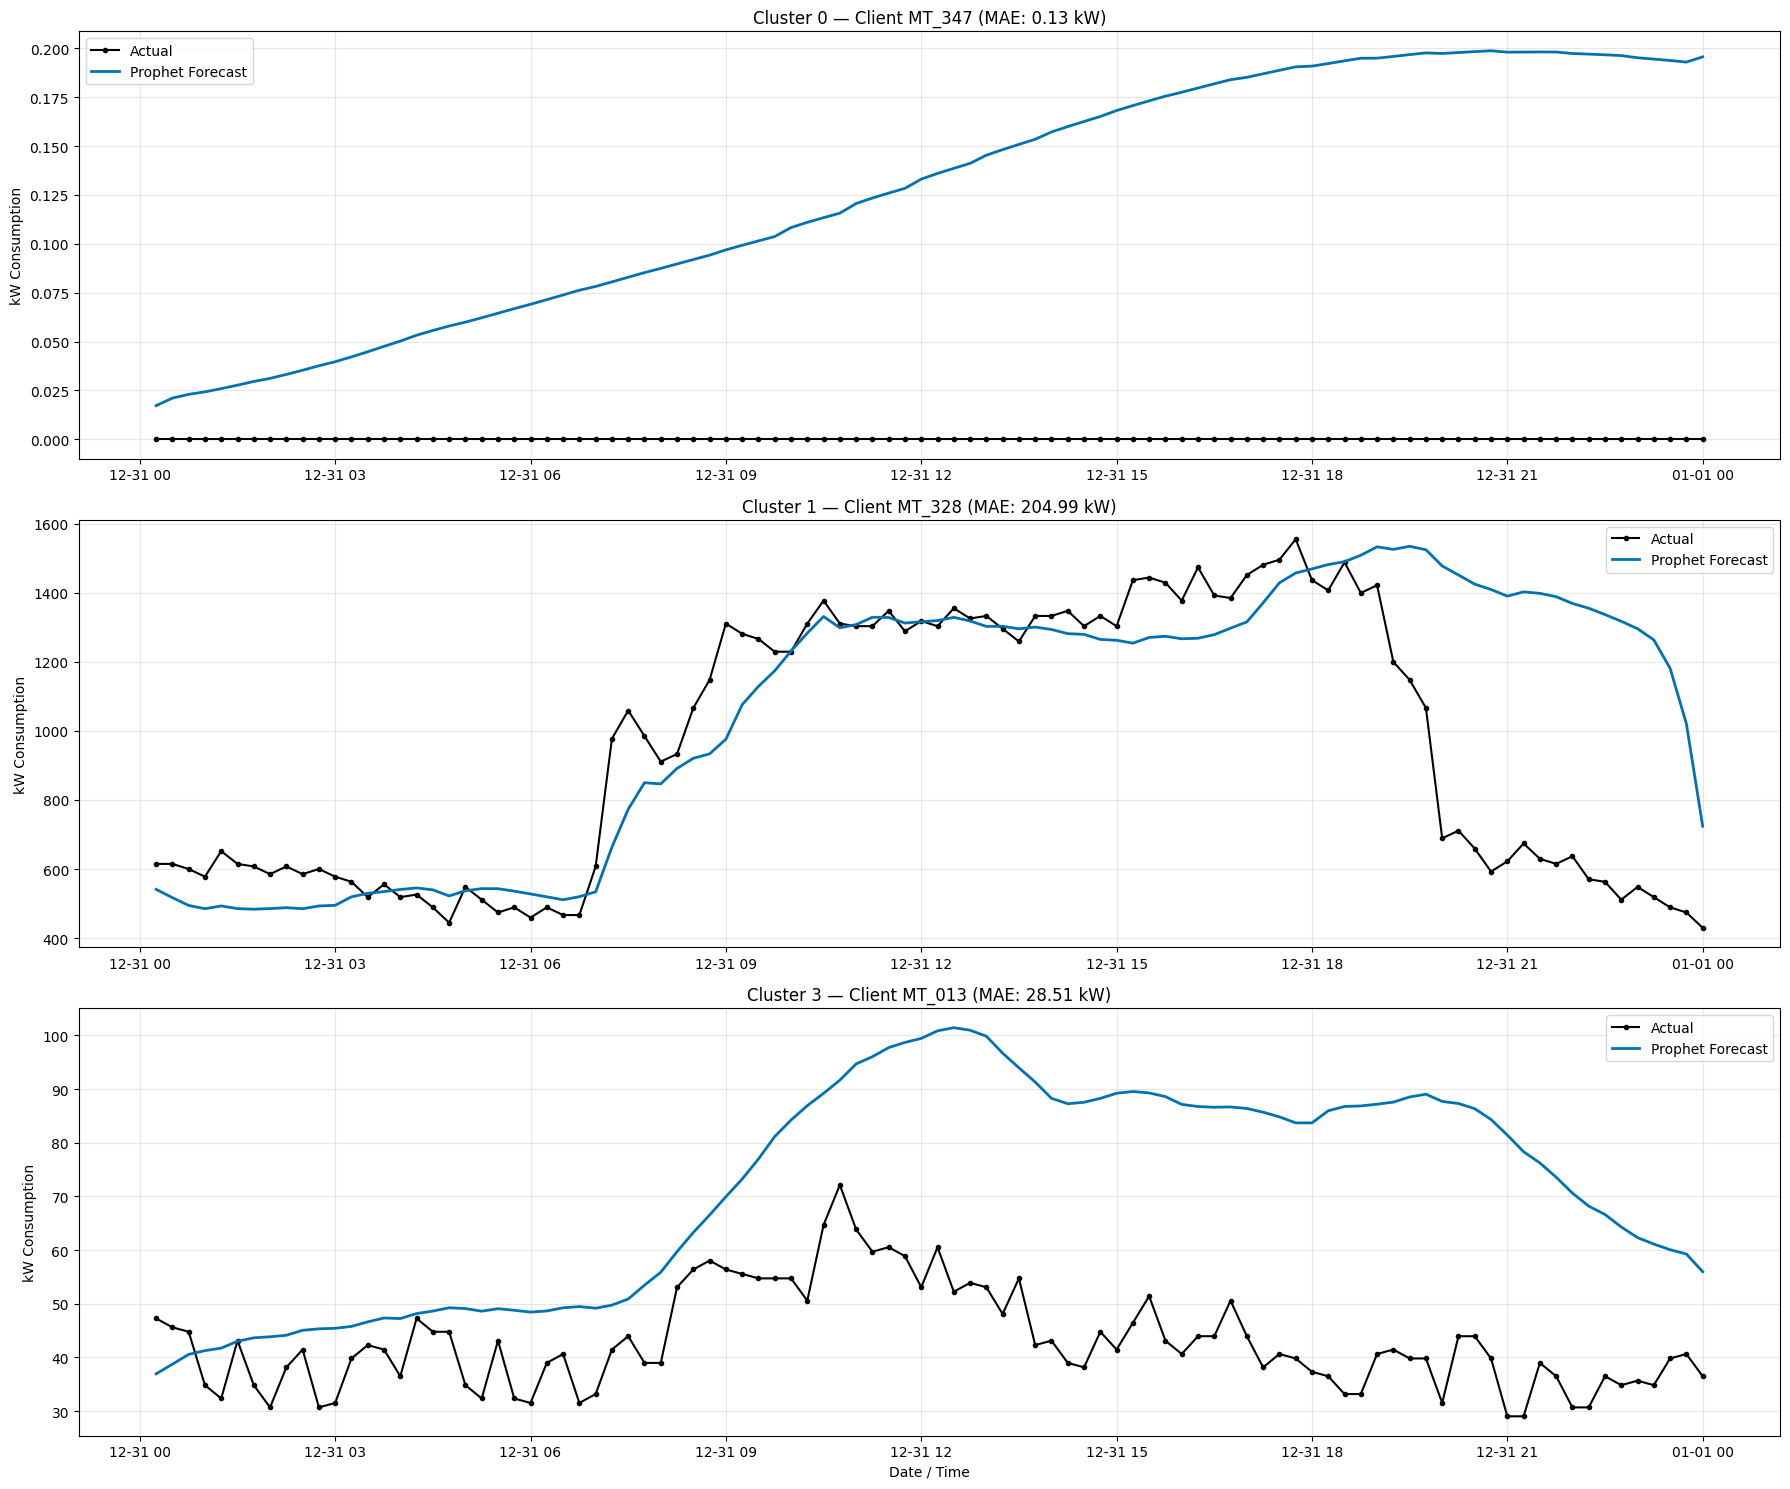

In [8]:
# ---------------------------------------------------------
# 6. Visualization: One Client per Cluster
# ---------------------------------------------------------

# Build a lookup: for each cluster, pick the first sampled client in that cluster
cluster_representatives = (
    results_df.groupby('Cluster')['ClientID'].first().to_dict()
)

fig, axes = plt.subplots(len(cluster_representatives), 1, figsize=(18, 5 * len(cluster_representatives)))

for idx, (cluster_id, client_id) in enumerate(sorted(cluster_representatives.items())):
    ax = axes[idx] if len(cluster_representatives) > 1 else axes
    
    data = all_predictions[client_id]
    
    # Plot
    ax.plot(data['test_df']['ds'].values, data['test_df']['y'].values, 
            label='Actual', color='black', marker='.', linestyle='-')
    ax.plot(data['test_df']['ds'].values, data['y_pred'], 
            label='Prophet Forecast', color='#0072B2', linewidth=2)
    
    client_mae = results_df[results_df['ClientID'] == client_id]['MAE'].values[0]
    ax.set_title(f"Cluster {cluster_id} — Client {client_id} (MAE: {client_mae:.2f} kW)")
    ax.set_ylabel('kW Consumption')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date / Time')
plt.tight_layout()
plt.show()